In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import csv
import re
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import torch
from torchvision import datasets, transforms
from tqdm import tqdm
import numpy as np
import random
from itertools import combinations
from collections import defaultdict
from sklearn.decomposition import PCA

import src.architectures.networkArchitectures as netArch
from src.robustness.general_classes import ModelBridge
from src.robustness.milp_functions import *
from src.architectures.networkArchitectures import networkRegistry
from src.robustness.exactRobustness import exactRobustness
from src.robustness.fastLin import fastLin
from src.testing.networkTesting import testNetwork
from src.training.networkTraining import trainNetwork, saveNetwork
from src.utils.extractParams import extractParams
from src.utils.loadNetwork import loadNetwork

In [11]:
images_dir = Path("generated_images/Exp3MultimodelGeneratedImages/")
results_dir = Path("results/")
images_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)
classes_to_generate = (0, 1, 3)
INCLUDE_MISPREDICTED = False
df_exp1 = pd.read_csv("results/Exp1FastLinRobustnessResults.csv") 



In [ ]:
# --- Configuration ---
number_of_images_to_generate = 30
som_mode = "independent"

csv_path = results_dir / "Exp3MultiModelGenerationResults.csv"

network_names = list(netArch.networkRegistry.keys())
all_possible_pairs = list(combinations(network_names, 2))
selected_pairs = random.sample(all_possible_pairs, min(number_of_images_to_generate, len(all_possible_pairs)))

with csv_path.open(mode="a", newline="") as file:
    writer = csv.writer(file)
    if csv_path.stat().st_size == 0:
        writer.writerow(["network1", "network2", "target_class", "mode", "obj_val"])

    for net1_name, net2_name in selected_pairs:
        target_cls = random.choice(classes_to_generate)
        print(f"\n--- Generating MultiModel Sample: {net1_name} & {net2_name} | Class: {target_cls} ---")

        try:
            multimodel = MultiModel((784,))
            network_pair_pt = []
            for name in [net1_name, net2_name]:
                NetClass = netArch.networkRegistry[name].NetworkClass
                model = NetClass()
                model.load_state_dict(torch.load(f'networks/{name}.pth', map_location='cpu'))
                model.eval()
                network_pair_pt.append(model)
            
            multimodel.add_networks(network_pair_pt)
            image, obj_val = generate_multi_model_input(multimodel, target_cls, mode=som_mode)
            
            if image is not None:
                img_filename = f"{net1_name}_{net2_name}_{target_cls}_{som_mode.replace(' ', '_')}.png"
                plt.imsave(images_dir / img_filename, image.reshape(28, 28), cmap='gray')
                writer.writerow([net1_name, net2_name, target_cls, som_mode, obj_val])
                file.flush()
        except Exception as e:
            print(f"  [Error]: {e}")
        finally:
            if hasattr(multimodel, 'g_model'):
                multimodel.g_model.dispose()

In [ ]:
# --- Fast-Lin Test ---
filePath = results_dir / "Exp3FastLinOnMultiModelSamples.csv"
pNorm = 1 

computed_tests = set()
if filePath.exists():
    with filePath.open(mode="r") as f:
        reader = csv.reader(f)
        next(reader, None)
        for row in reader:
            if row: computed_tests.add((row[0], row[5])) # (TestingNet, Filename)

with filePath.open(mode="a", newline="") as file:
    writer = csv.writer(file)
    if filePath.stat().st_size == 0:
        writer.writerow(["testing_network", "gen_net1", "gen_net2", "target_class", "predicted_class", "mode", "filename", "fastlin_eps"])

    image_files = [f for f in os.listdir(images_dir) if f.endswith(".png")]

    for networkName in netArch.networkRegistry.keys():
        NetworkClass = netArch.networkRegistry[networkName].NetworkClass
        test_net = NetworkClass()
        test_net.load_state_dict(torch.load(f'networks/{networkName}.pth', map_location='cpu'))
        test_net.eval()
        
        params = extractParams(network=test_net, inputShape=(1, 28, 28))
        weights, biases = [W for W, _ in params], [b for _, b in params]

        for img_name in tqdm(image_files, desc=f"Testing {networkName}"):
            if (networkName, img_name) in computed_tests: continue

            try:
                parts = img_name.replace(".png", "").split("_")
                n1, n2, t_cls, s_mode = parts[0], parts[1], int(parts[2]), "_".join(parts[3:])
                x0 = plt.imread(images_dir / img_name).flatten().astype(np.float32)
                
                img_torch = torch.from_numpy(x0).unsqueeze(0)
                with torch.no_grad():
                    pred_cls = torch.argmax(test_net(img_torch), dim=1).item()

                targetClasses = [c for c in range(10) if c != pred_cls]
                eps, _, _ = fastLin(weights=weights, biases=biases, x0=x0, pNorm=pNorm, 
                                    epsilon0=10, originalClass=pred_cls, 
                                    targetClasses=targetClasses, tolerance=0.005)

                writer.writerow([networkName, n1, n2, t_cls, pred_cls, s_mode, img_name, eps])
                file.flush()
            except Exception as e:
                print(f" Error {img_name}: {e}")

In [ ]:
# --- MultiModel Transferability Analysis ---

df_exp3 = pd.read_csv("results/Exp3FastLinOnMultiModelSamples.csv")

if not INCLUDE_MISPREDICTED:
    df_exp3 = df_exp3[df_exp3['target_class'] == df_exp3['predicted_class']].copy()

mnist_means = df_exp1.groupby('label')['epsilon'].mean()
df_exp3['is_generator'] = (df_exp3['testing_network'] == df_exp3['gen_net1']) | (df_exp3['testing_network'] == df_exp3['gen_net2'])

gen_means = df_exp3[df_exp3['is_generator']].groupby('target_class')['fastlin_eps'].mean()
outside_means = df_exp3[~df_exp3['is_generator']].groupby('target_class')['fastlin_eps'].mean()

target_classes = sorted(df_exp3['target_class'].unique())
plot_df = pd.DataFrame([{
    'Class': f"Class {c}",
    'MNIST Baseline': mnist_means.get(c, 0),
    'Inside Generator Pair': gen_means.get(c, 0),
    'Outside Networks': outside_means.get(c, 0)
} for c in target_classes]).set_index('Class')

x = np.arange(len(target_classes))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, plot_df['MNIST Baseline'], width, label='MNIST Baseline', color='#95a5a6')
ax.bar(x, plot_df['Inside Generator Pair'], width, label='Inside Generator Pair', color='#9b59b6')
ax.bar(x + width, plot_df['Outside Networks'], width, label='Outside Networks (Transfer)', color='#1abc9c')

ax.set_title('MultiModel Transferability: Shared vs. Outside Robustness', fontweight='bold')
ax.set_ylabel('Average $\epsilon$ (Fast-Lin)')
ax.set_xticks(x); ax.set_xticklabels(plot_df.index); ax.legend()
plt.tight_layout(); plt.show()

In [5]:
# --- Generate Average Samples ---
avg_images_dir = Path("generated_images/Exp3AvgGeneratedImages/")
avg_images_dir.mkdir(parents=True, exist_ok=True)

# 1. Average MNIST
mnist_train = datasets.MNIST('./data', train=True, download=True, transform=transforms.ToTensor())
for cls in classes_to_generate:
    indices = [i for i, (_, label) in enumerate(mnist_train) if label == cls]
    avg_img = torch.stack([mnist_train[i][0] for i in indices]).mean(dim=0).squeeze().numpy()
    plt.imsave(avg_images_dir / f"Avg_MNIST_{cls}.png", avg_img, cmap='gray')

# 2. Average Exp 2 Generations
df_exp2 = pd.read_csv("results/Exp2FastLinOnGeneratedSamples.csv")
exp2_dir = Path("generated_images/Exp2GeneratedImages/")
for cls in classes_to_generate:
    files = df_exp2[df_exp2['target_class'] == cls]['filename'].unique()
    imgs = [plt.imread(exp2_dir / f)[:,:,0] if f.endswith('.png') else plt.imread(exp2_dir / f) for f in files if (exp2_dir / f).exists()]
    if imgs:
        plt.imsave(avg_images_dir / f"Avg_Exp2_{cls}.png", np.mean(imgs, axis=0), cmap='gray')

<>:80: SyntaxWarning: invalid escape sequence '\e'
<>:80: SyntaxWarning: invalid escape sequence '\e'
C:\Users\adaml\AppData\Local\Temp\ipykernel_5768\1670323167.py:80: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('Average Fast-Lin $\epsilon$', fontsize=12)
Testing Average Samples on Dense3x48: 100%|██████████| 6/6 [00:00<?, ?it/s]


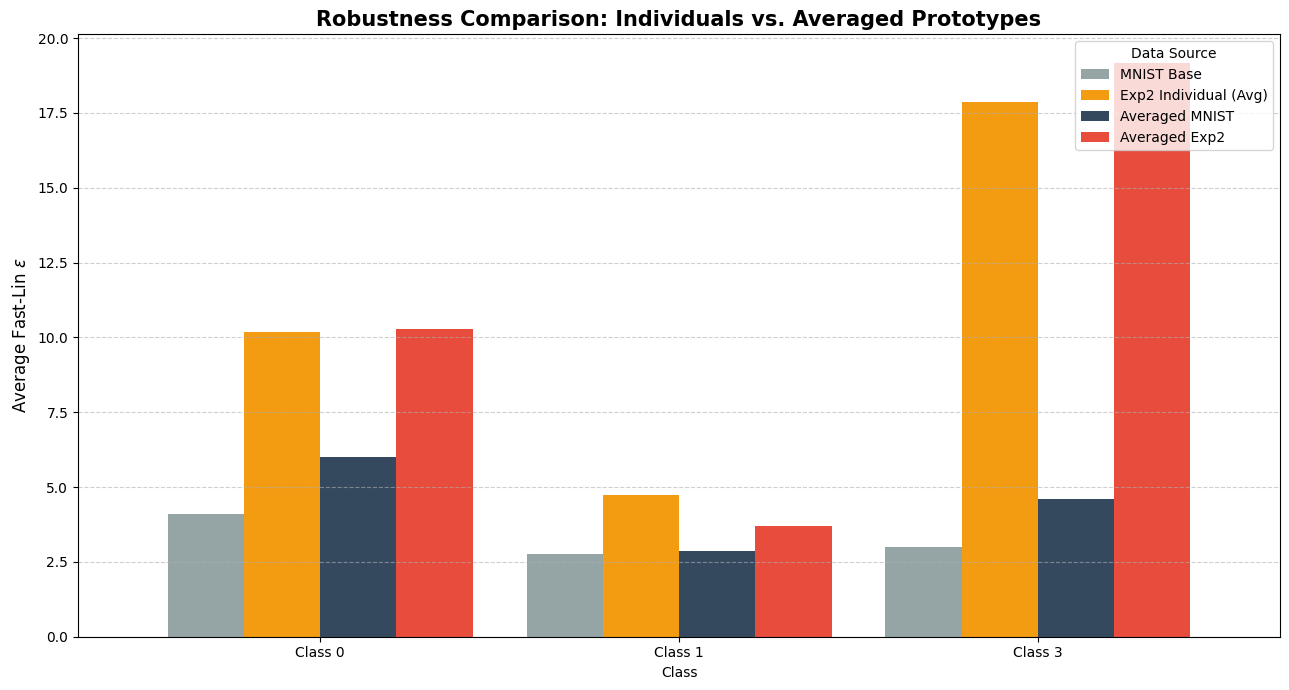

In [13]:
# --- 1. Test Averaged Samples ---
avg_results_path = results_dir / "Exp3FastLinOnAveragedSamples.csv"
pNorm = 1

computed_avg_tests = set()
if avg_results_path.exists():
    with avg_results_path.open(mode="r") as f:
        reader = csv.reader(f)
        next(reader, None)
        for row in reader:
            if row: computed_avg_tests.add((row[0], row[1]))

with avg_results_path.open(mode="a", newline="") as file:
    writer = csv.writer(file)
    if avg_results_path.stat().st_size == 0:
        writer.writerow(["testing_network", "filename", "source", "target_class", "predicted_class", "fastlin_eps"])

    avg_files = [f for f in os.listdir(avg_images_dir) if f.endswith(".png")]

    for networkName in netArch.networkRegistry.keys():
        test_net = netArch.networkRegistry[networkName].NetworkClass()
        test_net.load_state_dict(torch.load(f'networks/{networkName}.pth', map_location='cpu'))
        test_net.eval()
        
        params = extractParams(network=test_net, inputShape=(1, 28, 28))
        weights, biases = [W for W, _ in params], [b for _, b in params]

        for img_name in tqdm(avg_files, desc=f"Testing Average Samples on {networkName}"):
            if (networkName, img_name) in computed_avg_tests: continue

            img_raw = plt.imread(avg_images_dir / img_name)
            if img_raw.ndim == 3: img_raw = img_raw[:, :, 0]
            x0 = img_raw.flatten().astype(np.float32)

            parts = img_name.replace(".png", "").split("_")
            source, t_cls = parts[1], int(parts[2])
            
            img_torch = torch.from_numpy(x0).unsqueeze(0)
            with torch.no_grad():
                pred_cls = torch.argmax(test_net(img_torch), dim=1).item()

            eps, _, _ = fastLin(weights=weights, biases=biases, x0=x0, pNorm=pNorm, 
                                epsilon0=10, originalClass=pred_cls, 
                                targetClasses=[c for c in range(10) if c != pred_cls], tolerance=0.005)

            writer.writerow([networkName, img_name, source, t_cls, pred_cls, eps])
            file.flush()

# --- 2. Visualization ---
# Load Exp 3 results
df_avg = pd.read_csv(avg_results_path)
# Load Exp 2 results for the new comparison bar
df_exp2_raw = pd.read_csv("results/Exp2FastLinOnGeneratedSamples.csv")

if not INCLUDE_MISPREDICTED:
    df_avg = df_avg[df_avg['target_class'] == df_avg['predicted_class']].copy()
    df_exp2_raw = df_exp2_raw[df_exp2_raw['target_class'] == df_exp2_raw['predicted_class']].copy()

# Averages for Exp 3
avg_mnist_means = df_avg[df_avg['source'] == 'MNIST'].groupby('target_class')['fastlin_eps'].mean()
avg_exp2_means = df_avg[df_avg['source'] == 'Exp2'].groupby('target_class')['fastlin_eps'].mean()

# Average robustness for Exp 2 (averaged over all networks and SOM modes)
exp2_individual_means = df_exp2_raw.groupby('target_class')['fastlin_eps'].mean()

target_classes = sorted(df_avg['target_class'].unique())
plot_df_avg = pd.DataFrame([{
    'Class': f"Class {c}",
    'MNIST Base': df_exp1.groupby('label')['epsilon'].mean().get(c, 0),
    'Exp2 Individual (Avg)': exp2_individual_means.get(c, 0),
    'Averaged MNIST': avg_mnist_means.get(c, 0),
    'Averaged Exp2': avg_exp2_means.get(c, 0)
} for c in target_classes]).set_index('Class')

# Plotting with a distinct color palette
colors = ['#95a5a6', '#f39c12', '#34495e', '#e74c3c']
ax = plot_df_avg.plot(kind='bar', figsize=(13, 7), color=colors, width=0.85)

plt.title('Robustness Comparison: Individuals vs. Averaged Prototypes', fontsize=15, fontweight='bold')
plt.ylabel('Average Fast-Lin $\epsilon$', fontsize=12)
plt.legend(title="Data Source", frameon=True, loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
# --- PCA Generation ---
pca_images_dir = Path("generated_images/Exp3PCAGeneratedImages/")
pca_images_dir.mkdir(parents=True, exist_ok=True)

for cls in classes_to_generate:
    indices = [i for i, (_, label) in enumerate(mnist_train) if label == cls]
    data = torch.stack([mnist_train[i][0] for i in indices]).view(len(indices), -1).numpy()
    
    pca = PCA(n_components=10).fit(data)
    for i in range(5): # Generate 5 variations
        factor = (i - 2) * 2.5 
        new_img = np.clip(pca.mean_ + factor * pca.components_[0], 0, 1).reshape(28, 28)
        plt.imsave(pca_images_dir / f"PCA_MNIST_{cls}_var{i}.png", new_img, cmap='gray')

<>:69: SyntaxWarning: invalid escape sequence '\e'
<>:69: SyntaxWarning: invalid escape sequence '\e'
C:\Users\adaml\AppData\Local\Temp\ipykernel_5768\4130585117.py:69: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('Average Fast-Lin $\epsilon$')
Testing PCA Samples on Dense3x48: 100%|██████████| 15/15 [00:02<00:00,  5.48it/s]


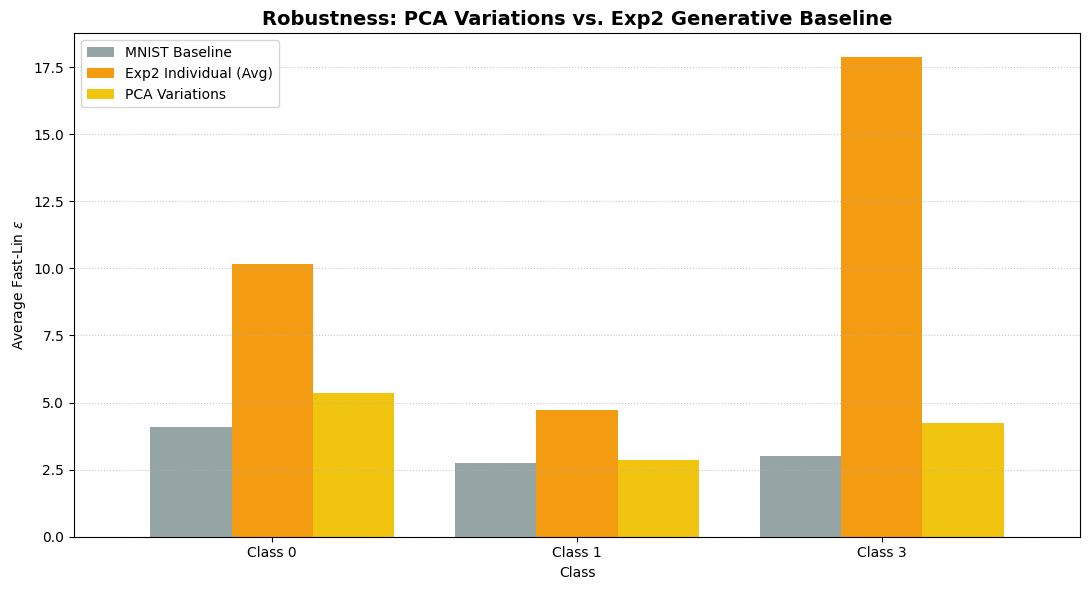

In [15]:
# --- 1. Test PCA Samples ---
pca_results_path = results_dir / "Exp3FastLinOnPCASamples.csv"

computed_pca_tests = set()
if pca_results_path.exists():
    with pca_results_path.open(mode="r") as f:
        reader = csv.reader(f)
        next(reader, None)
        for row in reader:
            if row: computed_pca_tests.add((row[0], row[1]))

with pca_results_path.open(mode="a", newline="") as file:
    writer = csv.writer(file)
    if pca_results_path.stat().st_size == 0:
        writer.writerow(["testing_network", "filename", "target_class", "variation", "predicted_class", "fastlin_eps"])

    pca_files = [f for f in os.listdir(pca_images_dir) if f.endswith(".png")]

    for networkName in netArch.networkRegistry.keys():
        test_net = netArch.networkRegistry[networkName].NetworkClass()
        test_net.load_state_dict(torch.load(f'networks/{networkName}.pth', map_location='cpu'))
        test_net.eval()
        
        params = extractParams(network=test_net, inputShape=(1, 28, 28))
        weights, biases = [W for W, _ in params], [b for _, b in params]

        for img_name in tqdm(pca_files, desc=f"Testing PCA Samples on {networkName}"):
            if (networkName, img_name) in computed_pca_tests: continue

            img_raw = plt.imread(pca_images_dir / img_name)
            if img_raw.ndim == 3: img_raw = img_raw[:, :, 0]
            x0 = img_raw.flatten().astype(np.float32)

            parts = img_name.replace(".png", "").split("_")
            t_cls, var_idx = int(parts[2]), parts[3]
            
            img_torch = torch.from_numpy(x0).unsqueeze(0)
            with torch.no_grad():
                pred_cls = torch.argmax(test_net(img_torch), dim=1).item()

            eps, _, _ = fastLin(weights=weights, biases=biases, x0=x0, pNorm=1, 
                                epsilon0=10, originalClass=pred_cls, 
                                targetClasses=[c for c in range(10) if c != pred_cls], tolerance=0.005)

            writer.writerow([networkName, img_name, t_cls, var_idx, pred_cls, eps])
            file.flush()

# --- 2. PCA Visualization ---
df_pca = pd.read_csv(pca_results_path)
# We use the same df_exp2_raw processed in Cell 6
if not INCLUDE_MISPREDICTED:
    df_pca = df_pca[df_pca['target_class'] == df_pca['predicted_class']].copy()

pca_means = df_pca.groupby('target_class')['fastlin_eps'].mean()
mnist_base = df_exp1.groupby('label')['epsilon'].mean()
# Use the same exp2_individual_means from Cell 6

plot_df_pca = pd.DataFrame([{
    'Class': f"Class {c}",
    'MNIST Baseline': mnist_base.get(c, 0),
    'Exp2 Individual (Avg)': exp2_individual_means.get(c, 0),
    'PCA Variations': pca_means.get(c, 0)
} for c in target_classes]).set_index('Class')

colors_pca = ['#95a5a6', '#f39c12', '#f1c40f']
ax = plot_df_pca.plot(kind='bar', figsize=(11, 6), color=colors_pca, width=0.8)

plt.title('Robustness: PCA Variations vs. Exp2 Generative Baseline', fontsize=14, fontweight='bold')
plt.ylabel('Average Fast-Lin $\epsilon$')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.xticks(rotation=0)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()